In [14]:
# fetch dataset 
from ucimlrepo import fetch_ucirepo 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets > 6 #This is to make a binary target 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=0)

y_train=y_train.values[:,0]
y_val=y_val.values[:,0]
y_test=y_test.values[:,0]




In [16]:
from sklearn.preprocessing import StandardScaler
X_sca = StandardScaler()
X_train = X_sca.fit_transform(X_train)
X_val = X_sca.fit_transform(X_val)
X_test = X_sca.fit_transform(X_test)



In [17]:
classifier_1=RandomForestClassifier(n_estimators=100,max_depth=None).fit(X_train,y_train)
classifier_2=DecisionTreeClassifier().fit(X_train,y_train)
classifier_3=LogisticRegression().fit(X_train,y_train)
classifier_4=LinearDiscriminantAnalysis().fit(X_train,y_train)

train_prediction_1=classifier_1.predict_proba(X_train)
train_prediction_2=classifier_2.predict_proba(X_train)
train_prediction_3=classifier_3.predict_proba(X_train)
train_prediction_4=classifier_3.predict_proba(X_train)

val_prediction_1=classifier_1.predict_proba(X_val)
val_prediction_2=classifier_2.predict_proba(X_val)
val_prediction_3=classifier_3.predict_proba(X_val)
val_prediction_4=classifier_3.predict_proba(X_val)



In [18]:
from sklearn.metrics import accuracy_score,log_loss


print('ACC 1 Train:',accuracy_score(y_train,train_prediction_1[:,1]>0.5),'Val:',accuracy_score(y_val,val_prediction_1[:,1]>0.5) )
print('ACC 2 Train:',accuracy_score(y_train,train_prediction_2[:,1]>0.5),'Val:',accuracy_score(y_val,val_prediction_2[:,1]>0.5) )
print('ACC 3 Train:',accuracy_score(y_train,train_prediction_3[:,1]>0.5),'Val:',accuracy_score(y_val,val_prediction_3[:,1]>0.5) )
print('ACC 4 Train:',accuracy_score(y_train,train_prediction_4[:,1]>0.5),'Val:',accuracy_score(y_val,val_prediction_4[:,1]>0.5) )



ACC 1 Train: 1.0 Val: 0.8623076923076923
ACC 2 Train: 1.0 Val: 0.8115384615384615
ACC 3 Train: 0.8257634077495509 Val: 0.8046153846153846
ACC 4 Train: 0.8257634077495509 Val: 0.8046153846153846


In [25]:
def train_model(model,n_data):
    model.fit(X_train[0:n_data],y_train[0:n_data])
    val_prediction=model.predict_proba(X_val)
    train_prediction=model.predict_proba(X_train)
    
    return accuracy_score(y_train,train_prediction[:,1]>0.5),accuracy_score(y_val,val_prediction[:,1]>0.5)
    #return log_loss(y_train,train_prediction[:,1]>0.5),log_loss(y_val,val_prediction[:,1]>0.5)



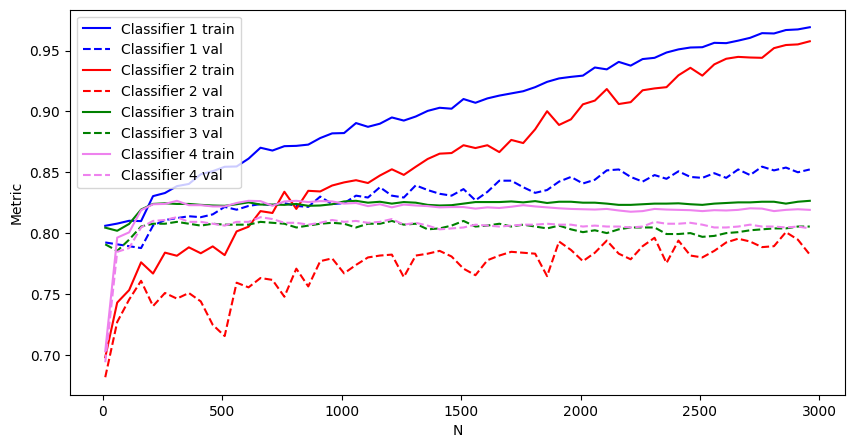

In [26]:
classifier_1=RandomForestClassifier(n_estimators=50,max_depth=None)
classifier_2=DecisionTreeClassifier()
classifier_3=LogisticRegression()
classifier_4=LinearDiscriminantAnalysis()
import matplotlib.pyplot as plt
points= list(range(10,3000,50))

f=plt.figure(figsize=(10,5))

t1,v1=zip(*[train_model(classifier_1,i) for i in points])
plt.plot(points,t1,label='Classifier 1 train',color='blue',linestyle='-')
plt.plot(points,v1,label='Classifier 1 val',color='blue',linestyle='--')

t2,v2=zip(*[train_model(classifier_2,i) for i in points])
plt.plot(points,t2,label='Classifier 2 train',color='red',linestyle='-')
plt.plot(points,v2,label='Classifier 2 val',color='red',linestyle='--')

t3,v3=zip(*[train_model(classifier_3,i) for i in points])
plt.plot(points,t3,label='Classifier 3 train',color='green',linestyle='-')
plt.plot(points,v3,label='Classifier 3 val',color='green',linestyle='--')


t4,v4=zip(*[train_model(classifier_4,i) for i in points])
plt.plot(points,t4,label='Classifier 4 train',color='violet',linestyle='-')
plt.plot(points,v4,label='Classifier 4 val',color='violet',linestyle='--')

plt.xlabel('N')
plt.ylabel('Metric')


plt.legend()
plt.show()

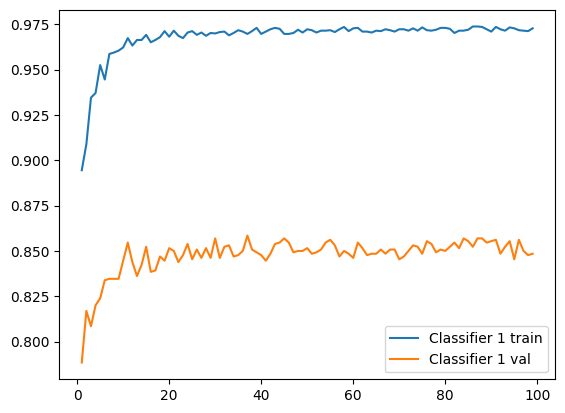

In [27]:
est=list(range(1,100,1))
t1,v1=zip(*[train_model(RandomForestClassifier(n_estimators=i,max_depth=None),3000) for i in est])
plt.plot(est,t1,label='Classifier 1 train')
plt.plot(est,v1,label='Classifier 1 val')

plt.legend()
plt.show()

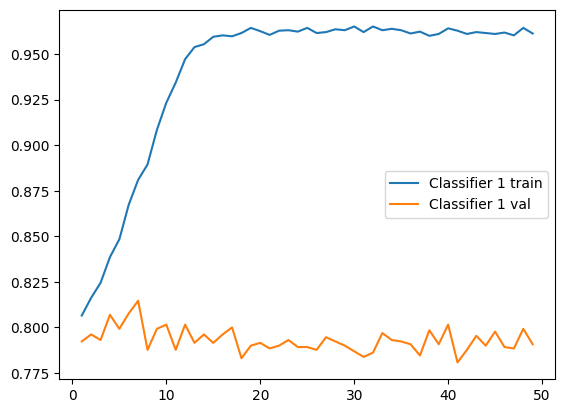

In [28]:
est=list(range(1,50,1))
t1,v1=zip(*[train_model(DecisionTreeClassifier(max_depth=i),3000) for i in est])
plt.plot(est,t1,label='Classifier 1 train')
plt.plot(est,v1,label='Classifier 1 val')
()
plt.legend()
plt.show()

In [68]:
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
import warnings


mlp_classifier=MLPClassifier(validation_fraction=0.2,max_iter=100)
#plt.plot(mlp_classifier.loss_curve_)
#plt.plot(mlp_classifier.validation_scores_)
#plt.show()

train_loss=[]
val_loss=[]
for i in range(100):
        mlp_classifier.partial_fit(X_train,y_train,classes=[0,1])
        train_loss.append(mlp_classifier.loss_)
        val_loss.append(log_loss(y_val,mlp_classifier.predict_proba(X_val)))
#est=list(range(1,100,1))
#t1,v1=zip(*[train_model(MLPClassifier(),3000) for i in est])
#plt.plot(est,t1,label='Classifier 1 train')
#plt.plot(est,v1,label='Classifier 1 val')

#plt.legend()
#plt.show()

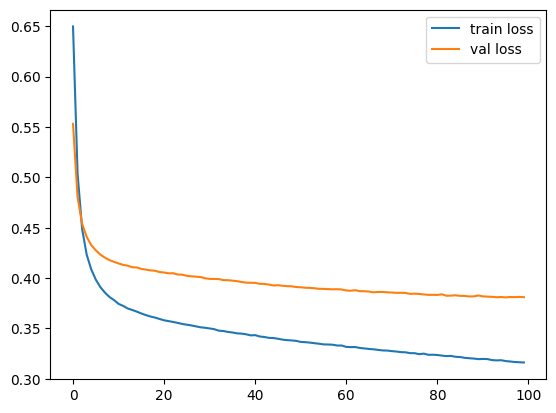

In [73]:
plt.plot(train_loss,label='train loss')
plt.plot(val_loss,label='val loss')
plt.legend()
plt.show()